In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('power_daily_clean.csv')
data = df['Global_active_power'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

prediction_days = 30
X, y = [], []

for i in range(prediction_days, len(scaled_data)):
    X.append(scaled_data[i-prediction_days:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [4]:
model = Sequential([
   
    Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    
    Bidirectional(LSTM(units=50)),
    Dropout(0.2),
    
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\admin\Desktop\AI\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
print("--- Đang huấn luyện mô hình BLSTM ---")
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test), verbose=1)

--- Đang huấn luyện mô hình BLSTM ---
Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0233 - val_loss: 0.0093
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115 - val_loss: 0.0073
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0113 - val_loss: 0.0072
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - val_loss: 0.0070
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115 - val_loss: 0.0082
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - val_loss: 0.0082
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0110 - val_loss: 0.0066
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0106 - val_loss: 0.0070
Epoch 9/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0106 - val_loss: 0.0074
Epoch 10/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - val_loss: 0.0064
Epoch 11/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0103 - val_loss: 0.0064
Epoch 12/25
36/36 ━━━━━━━

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


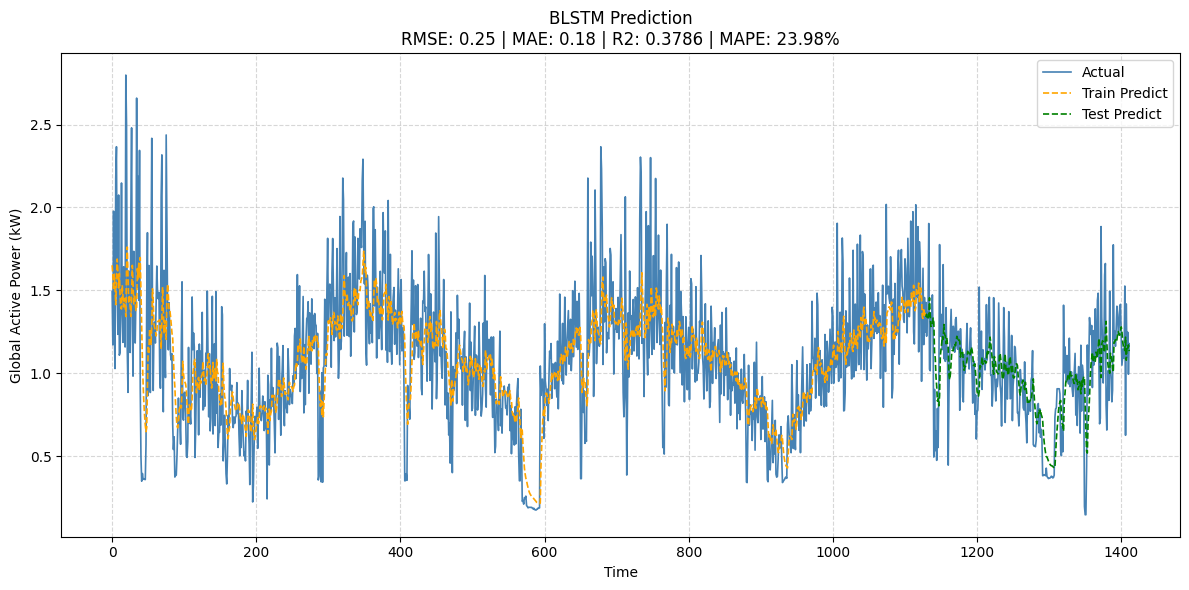

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Tính metrics
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mae = mean_absolute_error(y_test_unscaled, predictions)
r2 = r2_score(y_test_unscaled, predictions)
mape = np.mean(np.abs((y_test_unscaled - predictions) / y_test_unscaled)) * 100

# Dự báo trên tập train
train_predict = model.predict(X_train)
train_predict = scaler.inverse_transform(train_predict)
y_train_unscaled = scaler.inverse_transform(y_train.reshape(-1, 1))

plt.style.use('default')
plt.figure(figsize=(12, 6))

# Actual (toàn bộ)
plt.plot(range(len(y_train_unscaled) + len(y_test_unscaled)),
         np.concatenate([y_train_unscaled, y_test_unscaled]),
         color='steelblue', linewidth=1.2, label='Actual')

# Train Predict
plt.plot(range(len(train_predict)),
         train_predict,
         color='orange', linewidth=1.2, linestyle='--', label='Train Predict')

# Test Predict
plt.plot(range(len(y_train_unscaled), len(y_train_unscaled) + len(predictions)),
         predictions,
         color='green', linewidth=1.2, linestyle='--', label='Test Predict')

plt.title(f'BLSTM Prediction\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f} | MAPE: {mape:.2f}%')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()